# DataLoader

> Fastai DataLoader for spectroscopy data

In [ ]:
#| default_exp dataloader

In [ ]:
#| export
import pandas as pd
import numpy as np
import torch
from fastcore.all import *
import matplotlib.pyplot as plt
from fastai.torch_core import TensorBase
from fastai.data.block import DataBlock, TransformBlock
from kennard_stone import train_test_split as ks_split
from fastai.data.block import RegressionBlock
from fastai.torch_core import TitledFloat
from plum import dispatch
from pathlib import Path

import logging
logging.getLogger('kennard_stone').setLevel(logging.WARNING)


In [ ]:
#| export
def get_mir_k_1k_smp():
    "Load MIR Kex (exchangeable potassium) 1000 subsamples from OSSL"    
    url = "https://gist.githubusercontent.com/franckalbinet/613654a8908e5fa6bf131b9b267815f3/raw/0feb62ff4d0a26f2befb657aa87745b756de89b0/mir-k-subset-1000.csv"
    df = pd.read_csv(url)
    y = df.iloc[:, -1].to_numpy()
    X = df.iloc[:,:-1].to_numpy()
    wns = df.columns[:-1].to_numpy().astype(int)
    return X, y, wns

For instance:

In [ ]:
#| eval: false
X, y, wns = get_mir_k_1k_smp()
X.shape, y.shape, wns[:5]

((1000, 1701), (1000,), array([600, 602, 604, 606, 608]))

In [ ]:
#| export
def get_fuku_cs137(
    data_dir:Path, # Directory containing the CSV files
)->dict:    # Dict with keys 'train', 'test', 'wns', 'meta'
    "Load Fukushima Cs137 train/test/metadata"
    dfs = {s:pd.read_csv(data_dir/f'cs137_ratio_{s}.csv') for s in ('train','test')}
    dfs['meta'] = pd.read_csv(data_dir/'cs137_ratio_metadata.csv')
    spc_cols = [c for c in dfs['train'].columns if c[0]=='X']
    wns = np.array([int(c[1:]) for c in spc_cols])
    res = {}
    for k in ('train','test'):
        id_ = dfs[k]['ID'].to_numpy()
        X = dfs[k][spc_cols].to_numpy()
        y = dfs[k]['exCs137_totalCs137'].to_numpy()
        res[k] = dict(id=id_, X=X, y=y)
    res['wns'] = wns
    res['meta'] = dfs['meta']
    return res

In [ ]:
#| eval: false
data_fuku = get_fuku_cs137(Path('../_data/')); data_fuku.keys()

dict_keys(['train', 'test', 'wns', 'meta'])

In [ ]:
#| eval: false
wns_fuku = data_fuku['wns']
id_train, X_train, y_train = data_fuku['train'].values()
id_test, X_test, y_test = data_fuku['test'].values()
len(X_train), len(X_test)

(1194, 398)

## Splitters

In [ ]:
#| export
def get_ks_splitter(
    test_size=0.1,  # Proportion of data to hold out for testing
    valid_size=0.1, # Proportion of remaining data after test holdout for validation
)->callable:        # Function splitting (X,y) into train/valid/test idxs
    "Create a KS splitter returning train/valid/test indices"
    def _inner(X, y):
        train_val_X, test_X, train_val_idx, test_idx = ks_split(X, np.arange(len(X)), test_size=test_size)
        _, _, train_idx, valid_idx = ks_split(train_val_X, train_val_idx, test_size=valid_size / (1 - test_size))
        return train_idx, valid_idx, test_idx
    return _inner

In [ ]:
#| eval: false
X, y, wns = get_mir_k_1k_smp()
X.shape, y.shape, wns[:5]

((1000, 1701), (1000,), array([600, 602, 604, 606, 608]))

In [ ]:
#| eval: false
splitter = get_ks_splitter()
train_idx, valid_idx, test_idx = splitter(X, y)
train_idx[:5], valid_idx[:5], test_idx[:5]

(array([729, 475, 677, 362, 222]),
 array([962, 601, 865,   6, 737]),
 array([929,  73, 881, 551, 894]))

In [ ]:
#| export
def get_splitter(
    train_pct=0.8, # Proportion of data for training
    valid_pct=0.1, # Proportion of data for validation
    seed=42,       # Random seed for reproducibility
)->callable:       # Function splitting (X,y) into train/valid/test idxs
    "Create a random splitter returning train/valid/test indices"
    def _inner(X, y):
        if not np.isclose(train_pct + valid_pct + (1-train_pct-valid_pct), 1.0):
            raise ValueError("Split proportions must sum to 1")
        n = len(X)
        np.random.seed(seed)
        shuffled_idx = np.random.permutation(n)
        train_size = int(train_pct * n)
        valid_size = int(valid_pct * n)
        train_idx = shuffled_idx[:train_size]
        valid_idx = shuffled_idx[train_size:train_size + valid_size]
        test_idx = shuffled_idx[train_size + valid_size:]
        return train_idx, valid_idx, test_idx
    return _inner

In [ ]:
#| eval: false
splitter = get_splitter()
train_idx, valid_idx, test_idx = splitter(X, y)
train_idx[:5], valid_idx[:5], test_idx[:5]

(array([521, 737, 740, 660, 411]),
 array([556, 957, 577, 795,  85]),
 array([815, 862, 269, 201, 161]))

In [ ]:
#| export
def get_pre_splitter(
    n_train,    # Number of samples in pre-determined training set
    valid_pct=0.2, # Proportion of training samples for validation
    seed=42        # Random seed for reproducibility
)->callable:        # Function splitting (X,y) into train/valid/test idxs
    "Create splitter when first n_train samples form pre-defined training set"
    def _inner(X, y):
        n = len(X)
        train_idx = np.arange(n_train)
        test_idx = np.arange(n_train, n)
        valid_size = int(n_train * valid_pct)
        np.random.seed(seed)
        shuffled = np.random.permutation(train_idx)
        return shuffled[valid_size:], shuffled[:valid_size], test_idx
    return _inner

In [ ]:
#| eval: false
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
splitter = get_pre_splitter(n_train=len(X_train))

In [ ]:
#| eval: false
train_idx, valid_idx, test_idx = splitter(X_all, y_all)
test_idx[:5], len(train_idx), len(valid_idx), len(test_idx)

(array([1194, 1195, 1196, 1197, 1198]), 956, 238, 398)

## Data loader

In [ ]:
#| export
class SpectralTarget(TitledFloat):
    def show(self, ctx=None, **kwargs):
        if ctx is not None: ctx.set_title(f"Target: {self:.3f}")
        return ctx
        
    def __repr__(self): return f"{float(self):.3f}"

In [ ]:
#| eval: false
SpectralTarget(2.345678)

2.346

In [ ]:
#| export
class TensorSpectrum(TensorBase):
    wns = None  # set after loading data: TensorSpectrum.wns = wns

    def show(self, ctx=None, title=None, figsize=None, **kwargs):
        if ctx is None: _, ctx = plt.subplots(figsize=figsize)
        ctx.plot(self.__class__.wns, self.squeeze().cpu(), **kwargs)
        ctx.invert_xaxis()
        ctx.grid(True)
        if title is not None: ctx.set_title(f"Target value: {float(title):.3f}")
        return ctx
    
    def __repr__(self): return f"TensorSpectrum(shape={tuple(self.shape)})"

In [ ]:
#| eval: false
TensorSpectrum(X[0])

TensorSpectrum(shape=(1701,))

In [ ]:
#| export
@dispatch
def show_batch(
    x:TensorSpectrum, # Spectra (features)
    y, # Soil property (target)
    samples, 
    ctxs=None, 
    max_n=9, 
    ncols=3, 
    figsize=None, 
    **kwargs
    ):
    n = min(len(samples), max_n)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    if figsize is None: figsize = (6*ncols, 3*nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = np.array(axs).flatten()
    for s, ax in zip(samples[:n], axs[:n]):
        s[0].show(ctx=ax, title=s[1], **kwargs)
    for ax in axs[n:]: ax.axis('off')
    plt.tight_layout()

In [ ]:
#| export
def SpectralBlock():
    return TransformBlock(type_tfms=lambda x: TensorSpectrum(torch.tensor(x, dtype=torch.float32).unsqueeze(0)))

In [ ]:
#| export
def RegressionFloatBlock():
    return TransformBlock(type_tfms=lambda x: SpectralTarget(x))

In [ ]:
#| export
def get_spectral_dls(
    X,            # Spectral data matrix
    y,            # Target values
    wns,          # Wavenumbers
    splitter=None,# Function returning train/valid/test idxs
    bs=32         # Batch size
)->tuple:         # (DataLoaders, test_indices) for training/validation/testing
    "Create DataLoaders for spectral data with train/valid/test split"
    if splitter is None: splitter = get_splitter()
    TensorSpectrum.wns = wns
    train_idx, valid_idx, test_idx = splitter(X, y)
    items = list(range(len(X)))
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    dblock = DataBlock(blocks=(SpectralBlock(), RegressionBlock()), splitter=_ds_splitter, get_x=lambda i: X[i], get_y=lambda i: y[i])
    return dblock.dataloaders(items, bs=bs), test_idx

For instance, with a dataset not yet train/test splittted:

In [ ]:
#| eval: false
dls, test_idx = get_spectral_dls(X, y, wns)

# or with KS:
# dls, test_idx = get_spectral_dls(X, y, wns, splitter=get_ks_splitter())

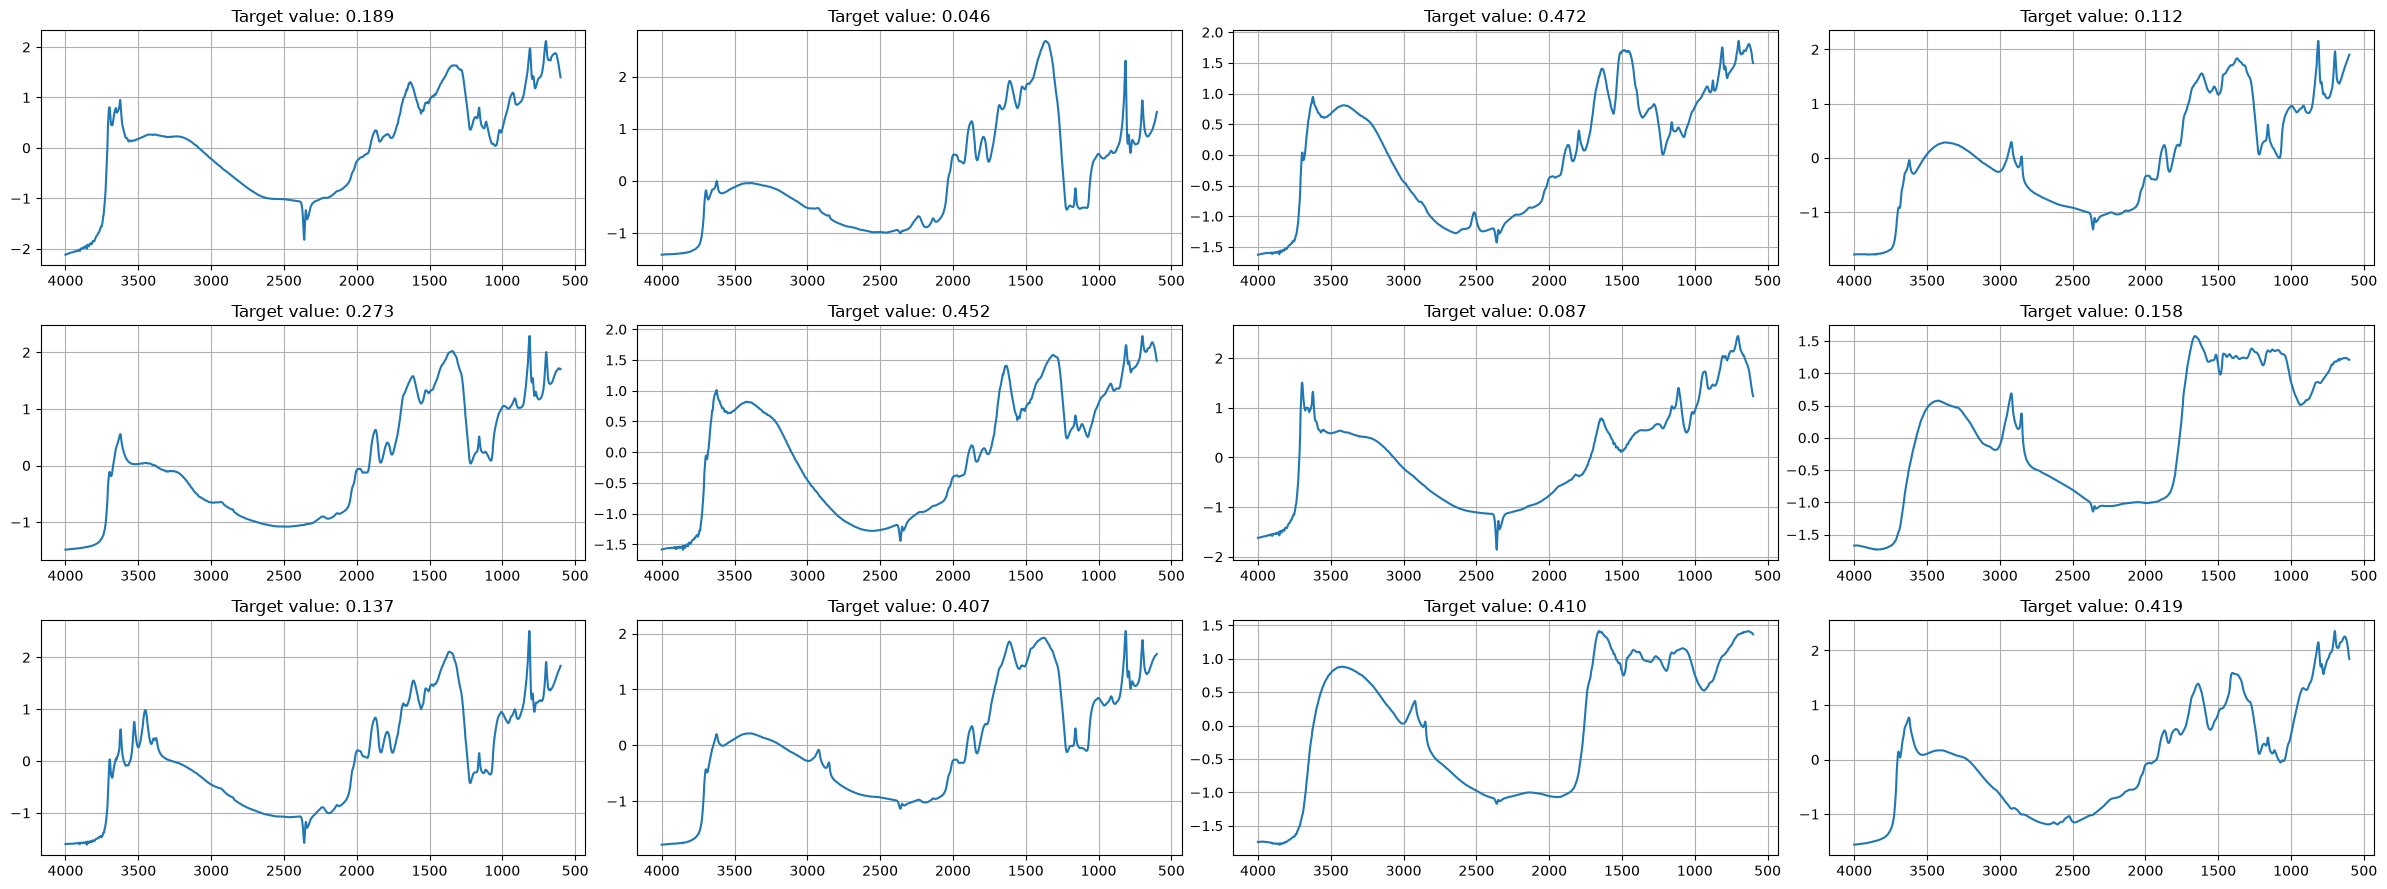

In [ ]:
#| eval: false
dls.show_batch(max_n=12, ncols=4)

or for a dataset which has been prelinimary splitted as train/test:

In [ ]:
#| eval: false
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
splitter = get_pre_splitter(n_train=len(X_train))

dls_fuku, test_idx = get_spectral_dls(X_all, y_all, wns_fuku, splitter=get_pre_splitter(n_train=len(X_train)))

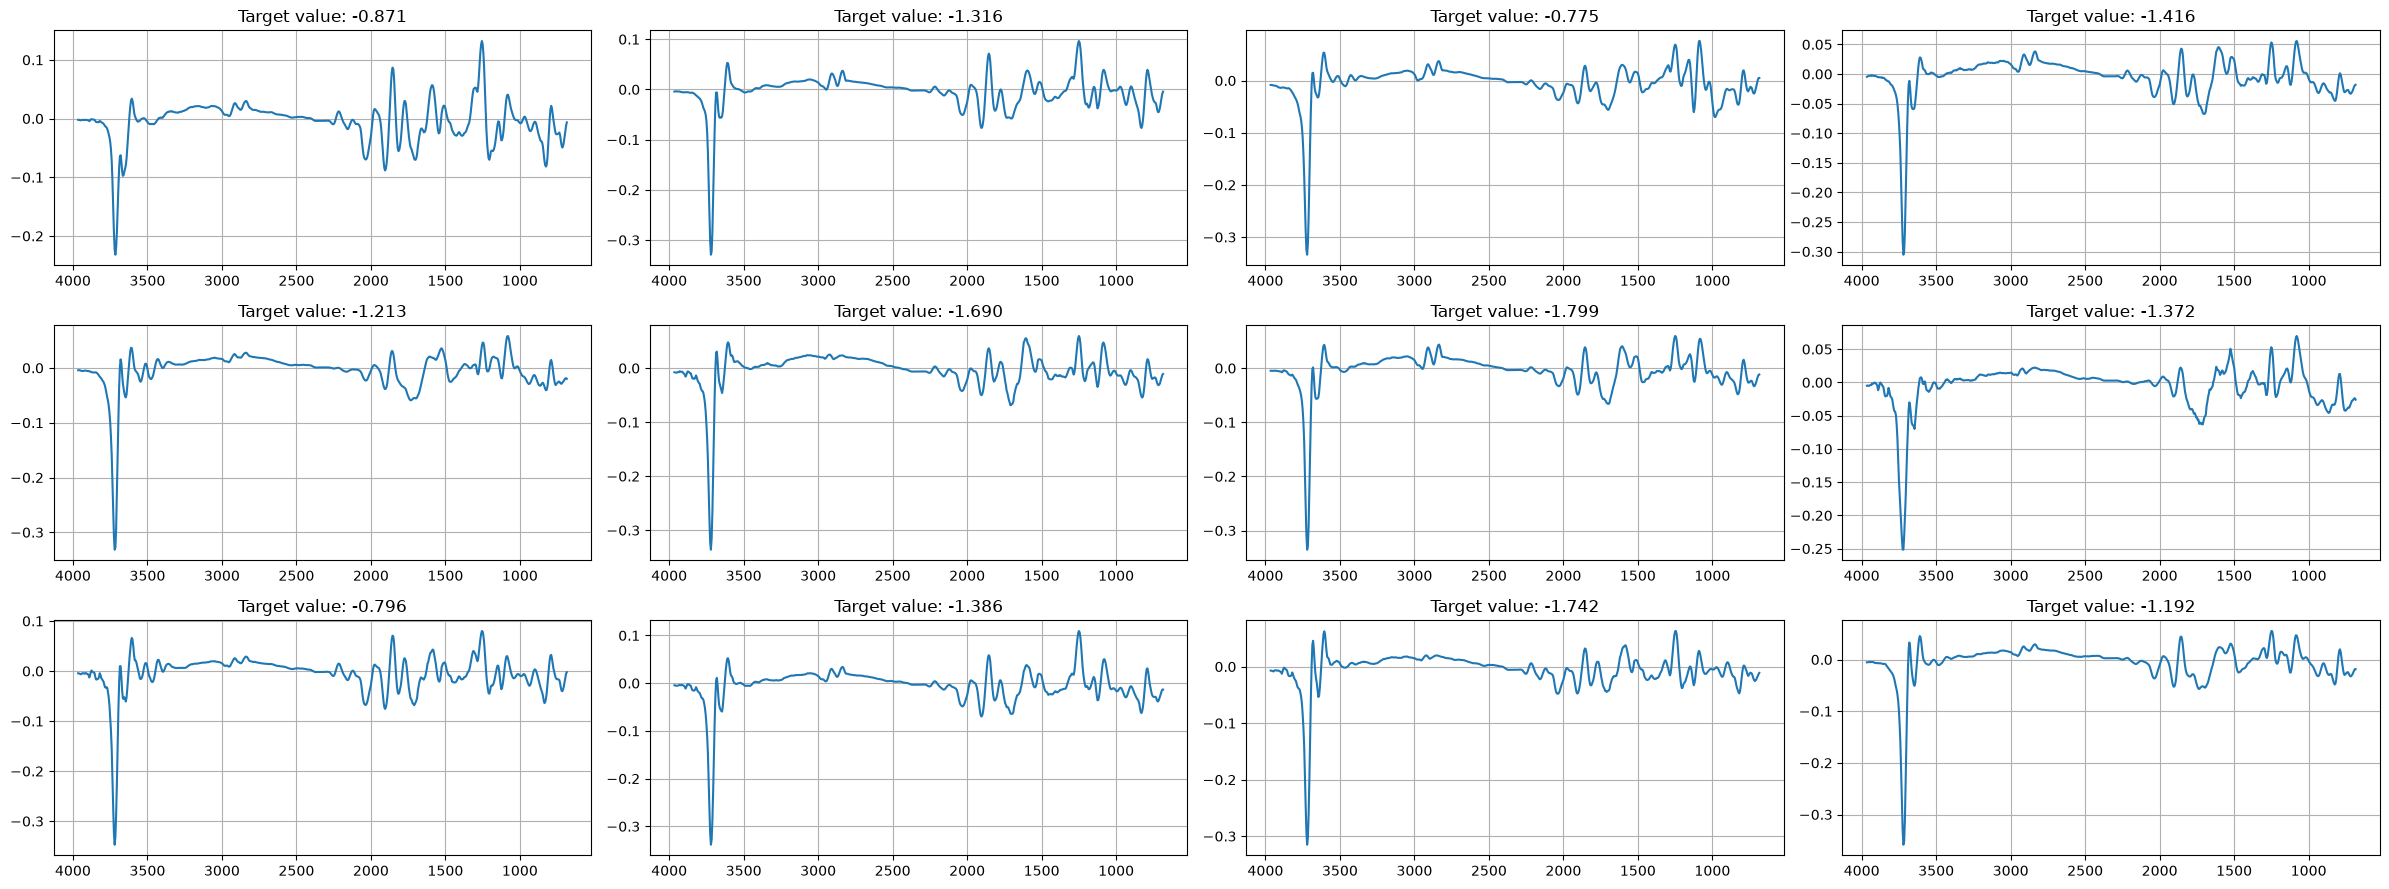

In [ ]:
#| eval: false
dls_fuku.show_batch(max_n=12, ncols=4)